<a href="https://colab.research.google.com/github/HurtovaAlina/ITStep-AI/blob/superwised_learning/DZ_Overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дані

In [46]:
import pandas as pd

In [47]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/ITStep-AI/refs/heads/superwised_learning/data/customer_spending.csv")

In [48]:
df.head()

,annual_income,account_tenure_days,age,engagement_score,support_tickets,annual_spending
0,57964.98,1170,65,35.95,5,218.46
1,27667.36,856,58,14.56,2,16.51
2,74068.69,1178,31,33.26,2,240.06
3,82232.89,741,33,87.93,2,242.77
4,16763.02,497,31,10.22,0,130.61


# Опис даних

Цу дані користувачів онлайн-сервісу **Shoply** — сайту, де люди купують товари та оформлюють підписки. Для кожного користувача зібрана інформація про його активність, дохід та взаємодію із сайтом.

* **annual_income** — скільки грошей користувач заробляє за рік
* **account_tenure_days** — скільки днів користувач зареєстрований на сайті
* **age** — вік користувача
* **engagement_score** — наскільки активно користувач користується сайтом
* **support_tickets** — скільки разів користувач звертався до служби підтримки
* **annual_spending** — скільки грошей користувач витрачає на сайті за рік


Потрібно спрогнозувати **витрати** користувача

# Завдання 1
Розділіть дані на ознаки для моделі(Х) та цільову змінну(y)

In [49]:
y = df['annual_spending']
X = df.drop(columns='annual_spending')


X.head()

,annual_income,account_tenure_days,age,engagement_score,support_tickets
0,57964.98,1170,65,35.95,5
1,27667.36,856,58,14.56,2
2,74068.69,1178,31,33.26,2
3,82232.89,741,33,87.93,2
4,16763.02,497,31,10.22,0


# Завдання 2
Розділіть дані на тренувальну та тестову вибірку

In [50]:
# розділити данні на тренувальні та тестові
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.8,
                                                    random_state=42
                                                    )

X_train.shape, X_test.shape

((5216, 5), (1304, 5))

#Завдання 3
Нетренуйте дерево рішень на тренувальній вибірці

При створенні моделі використовуйте параметри за замовчуванням

In [51]:
from sklearn.tree import DecisionTreeRegressor


model_tree = DecisionTreeRegressor()

# натренувати модель
model_tree.fit(X_train, y_train)

DecisionTreeRegressor()

# Завдання 4
Спронозуйте витрати користувача для тренувальних даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [52]:
y_train_pred = model_tree.predict(X_train)
y_train_pred

array([246.92,   0.  ,  22.54, ..., 189.18, 246.96,  32.77])

In [53]:
comparison = pd.DataFrame({
    'Справжня ціна': y_train,
    'Прогнозована ціна': y_train_pred
})

comparison.head(10)

,Справжня ціна,Прогнозована ціна
1580,246.92,246.92
3077,0.00,0.00
4857,22.54,22.54
1436,62.32,62.32
6403,108.80,108.80
2370,87.68,87.68
3477,109.39,109.39
3370,74.23,74.23
2268,73.53,73.53
90,190.14,190.14


In [54]:
# Метрики

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# прогноз для тренувальних даних
mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
r2 = r2_score(y_train, y_train_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 0.0
MSE: 0.0
R2: 1.0


# Завдання 5
Спронозуйте витрати користувача для тестових даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [55]:
# Прогноз ціни для тестових даних
y_test_pred = model_tree.predict(X_test)

# Порівняння справжньої та прогнозованої ціни
comparison = pd.DataFrame({
    'Справжня ціна': y_test,
    'Прогнозована ціна': y_test_pred
})

comparison.head(10)

,Справжня ціна,Прогнозована ціна
5573,186.50,162.50
2921,156.03,116.40
5027,144.97,133.23
1176,87.41,120.26
3886,81.18,10.96
3176,194.57,127.27
3214,188.22,212.47
6017,91.49,35.98
4649,128.35,151.79
5836,170.40,196.01


In [56]:
# прогноз для тестових даних
# MAE
mae = mean_absolute_error(y_test, y_test_pred)

# MSE
mse = mean_squared_error(y_test, y_test_pred)

# R2
r2 = r2_score(y_test, y_test_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 33.16677147239264
MSE: 1740.4103884202452
R2: 0.5064075411024339


# Завдання 6
Для різних значень параметра `max_depth` натренуйте модель та порахуйте метрику `MAE` на тренувальних та тестових даних

Отримайте відповідно 2 списки -- `train_mae` та `test_mae`
візуалізуйте їх

In [57]:
train_mae = []
test_mae = []

max_depths = range(1,10)

for depth in max_depths:
    # Створюємо модель
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    # Навчаємо модель
    model.fit(X_train, y_train)

    # Прогноз для тренувальних даних
    y_train_pred = model.predict(X_train)

    # Прогноз для тестових даних
    y_test_pred = model.predict(X_test)

    # MAE для train
    train_mae.append(mean_absolute_error(y_train, y_train_pred))

    # MAE для test
    test_mae.append(mean_absolute_error(y_test, y_test_pred))

In [58]:
print("train_mae:", train_mae)
print("test_mae:", test_mae)

train_mae: [35.63177445860968, 31.6251986946527, 28.224786744448036, 25.784014724992396, 23.84374721400964, 22.670991151668908, 21.590362728677473, 20.594217460219273, 19.286970682279446]
test_mae: [36.28863469376777, 32.37055994240308, 28.151793095055726, 26.266120493435206, 23.861328317389244, 23.77990553894696, 24.052961076583383, 24.576712023137336, 25.075350879336153]


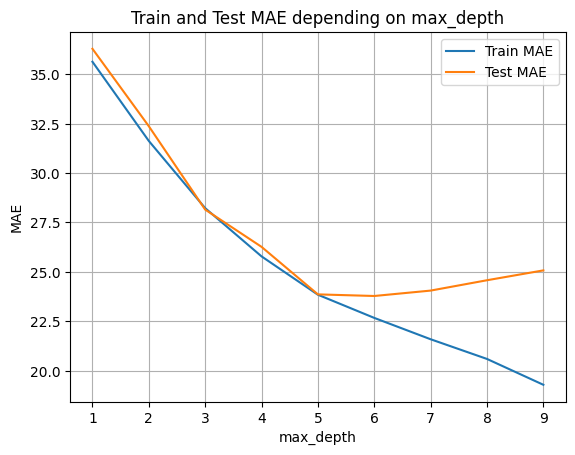

In [59]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mae, label="Train MAE")
plt.plot(max_depths, test_mae, label="Test MAE")

plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

In [60]:
# MSE

train_mse = []
test_mse = []

max_depths = range(1,10)

for depth in max_depths:
    # Створюємо модель
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    # Навчаємо модель
    model.fit(X_train, y_train)

    # Прогноз для тренувальних даних
    y_train_pred = model.predict(X_train)

    # Прогноз для тестових даних
    y_test_pred = model.predict(X_test)

    # MAE для train
    train_mse.append(mean_squared_error(y_train, y_train_pred))

    # MAE для test
    test_mse.append(mean_squared_error(y_test, y_test_pred))

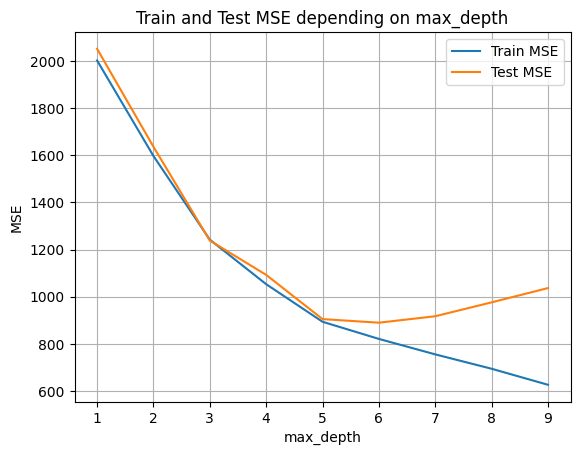

In [61]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mse, label="Train MSE")
plt.plot(max_depths, test_mse, label="Test MSE")

plt.xlabel("max_depth")
plt.ylabel("MSE")
plt.title("Train and Test MSE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

In [62]:
train_R2 = []
test_R2 = []

max_depths = range(1,10)

for depth in max_depths:
    # Створюємо модель
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    # Навчаємо модель
    model.fit(X_train, y_train)

    # Прогноз для тренувальних даних
    y_train_pred = model.predict(X_train)

    # Прогноз для тестових даних
    y_test_pred = model.predict(X_test)

    # MAE для train
    train_R2.append(r2_score(y_train, y_train_pred))

    # MAE для test
    test_R2.append(r2_score(y_test, y_test_pred))

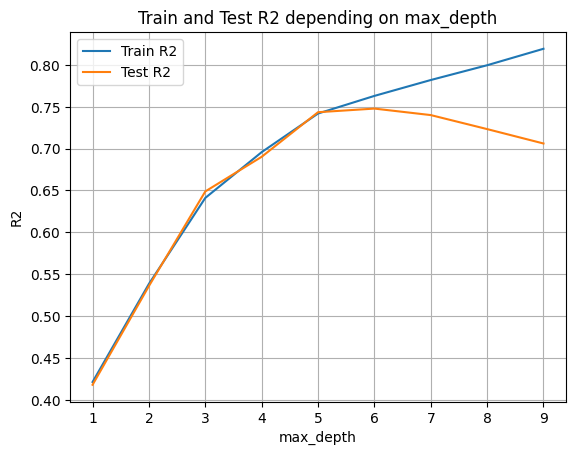

In [63]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_R2, label="Train R2")
plt.plot(max_depths, test_R2, label="Test R2")

plt.xlabel("max_depth")
plt.ylabel("R2")
plt.title("Train and Test R2 depending on max_depth")
plt.legend()
plt.grid()

plt.show()

# Завдання 7
По графіку визначте оптимальне значення параметра `max_depth`

In [64]:
# оптимальне max_depth = 5
# будуємо дерево з max_depth = 5
# Оптимальна максимальна глибина дерева — max_depth=5, оскільки при цьому значенні Test MAE досягає найменшого значення.
# Подальше збільшення глибини дерева зменшує помилку на тренувальних даних, але збільшує помилку на тестових даних, що
# може свідчити про перенавчання моделі.

model_tree = DecisionTreeRegressor(max_depth = 5)

# натренувати модель
model_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5)

In [65]:
# Прогноз для тренувальних даних

y_train_pred = model_tree.predict(X_train)
y_train_pred

array([281.88769231,  23.610625  ,  57.9954386 , ..., 134.82125   ,
       201.50855856,  55.00380952])

In [66]:
# Прогноз ціни для тестових даних
y_test_pred = model_tree.predict(X_test)

# Порівняння справжньої та прогнозованої ціни
comparison = pd.DataFrame({
    'Справжня ціна': y_test,
    'Прогнозована ціна': y_test_pred
})

comparison.head(10)

,Справжня ціна,Прогнозована ціна
5573,186.50,177.291313
2921,156.03,149.848855
5027,144.97,134.821250
1176,87.41,109.021376
3886,81.18,56.577368
3176,194.57,149.848855
3214,188.22,177.291313
6017,91.49,79.327991
4649,128.35,134.821250
5836,170.40,177.291313


In [67]:
# MAE
mae = mean_absolute_error(y_test, y_test_pred)

# MSE
mse = mean_squared_error(y_test, y_test_pred)

# R2
r2 = r2_score(y_test, y_test_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 23.861328317389248
MSE: 904.500386789135
R2: 0.7434774160396207


MAE зменшилася з 32.60 до 23.86. Це означає, що в середньому помилка прогнозу стала меншою.

MSE також суттєво зменшилася — з 1696.49 до 904.50, тобто модель робить менше великих помилок.

R² збільшилася з 0.519 до 0.743. Тепер модель пояснює приблизно 74,3% варіації ціни замість 51,9%.

In [68]:
# порівняємо з max_depth = 6

model_tree = DecisionTreeRegressor(max_depth = 6)

# натренувати модель
model_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=6)

In [69]:
# Прогноз для тренувальних даних

y_train_pred = model_tree.predict(X_train)
y_train_pred

array([283.88114943,  21.9416129 ,  64.62615385, ..., 140.97303371,
       194.47707483,  38.6025    ])

In [70]:
# Прогноз ціни для тестових даних
y_test_pred = model_tree.predict(X_test)

# Порівняння справжньої та прогнозованої ціни
comparison = pd.DataFrame({
    'Справжня ціна': y_test,
    'Прогнозована ціна': y_test_pred
})

comparison.head(10)

,Справжня ціна,Прогнозована ціна
5573,186.50,181.926263
2921,156.03,156.042000
5027,144.97,127.598179
1176,87.41,100.085509
3886,81.18,28.370000
3176,194.57,156.042000
3214,188.22,181.926263
6017,91.49,87.157826
4649,128.35,140.973034
5836,170.40,167.243285


In [71]:
# MAE
mae = mean_absolute_error(y_test, y_test_pred)

# MSE
mse = mean_squared_error(y_test, y_test_pred)

# R2
r2 = r2_score(y_test, y_test_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 23.779905538946963
MSE: 889.2331008254794
R2: 0.7478073242438192


при max_depth=6:

MAE трохи менша → помилка прогнозу менша;

MSE менша → великих помилок трохи менше;

R² більша → модель пояснює трохи більше варіації даних.